<a href="hhttps://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab2/L2_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2.3 Time and frequency domain calculations and analysis using ADXL345 data



For this section of Lab 2, have ready in hand all CSV files (highest rate outcome of 3200 Hz) from each activity: no fan, fan in normal condition, and  fan in anomalous condition.

For this portion of the lab, you will no longer need to use the Raspberry PI as you already have the data collected.

**You will run all your code using this Colab notebook**

## 3.1 Signal Processing and plotting data from: Fan off data

### Reading a CSV file and plotting data

In this part, we will read the saved CSV file generated in Lab 2.2 and then plot the data. A sample code structure is given below. It includes frequency domain transformations as well. However, the plotting part of the FFT signals is incomplete. You should finish the incomplete part.

Please note that you must change the ‘filename’ variable according to the CSV file you saved in the previous part. By modifying and adding lines, try to calculate time domain features from each axis data in Table 1 in the Prelab 2.2, such as mean, standard deviation, root mean square, and so on.






Import essential libraries:

In [4]:
import matplotlib
#matplotlib.use('tkagg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io
import seaborn as sns
import csv

The following code allows you to upload the data stored in a csv file to this Colab notebook.

In [ ]:
#This code allows you to upload a file from your local drive
from google.colab import files
uploaded = files.upload()
#If you will work with excel, please save your file with a .CSV format
#Check the output file name below. You will use that file name in the next block.

The next coding block extracts information from the csv file, and saves it through arrays.
The FFT fourier code is incomplete (a_y, and a_z are not coded). Please finish coding it and plot it by uncommenting the plot code lines.

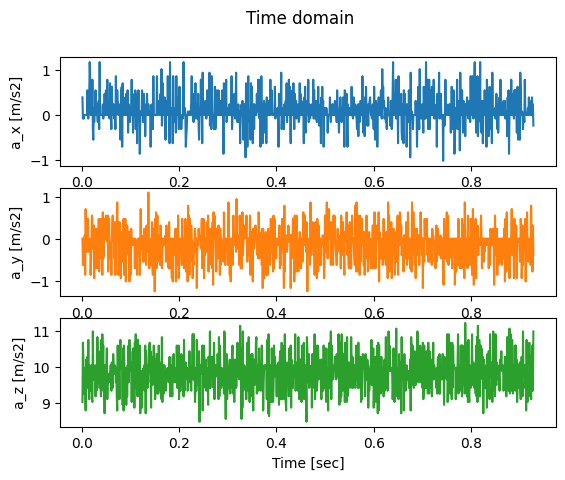

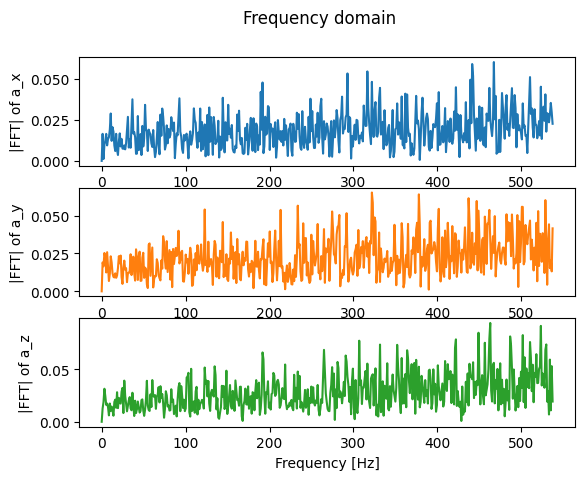

In [7]:
from pandas.core.internals.construction import dict_to_mgr

filename1 = './data/20260207_211118_lab2_fan_off.csv' #Insert the imported csv file name (copy the bolded text from the previous output) from the previous step inside the quotations
#Declaring arrays
dt = [] # sampling period list, dt
t = [] # time list, t
a_x = [] # x-axis acceleration list, a_x
a_y = [] # y-axis acceleration list, a_y
a_z = [] # z-axis acceleration list, a_z

# Reading a CSV file and convert rows as data

with open(filename1, 'r') as f:
    rows = csv.reader(f, delimiter = ',')
    header = next(rows)
    for row in rows:
        dt.append(float(row[0]))
        t.append(float(row[1]))
        a_x.append(float(row[2]))
        a_y.append(float(row[3]))
        a_z.append(float(row[4]))

N = int(len(dt)) # Number of sample = 1000
T = t[-1]/N # sampling period, assumed equally distributed


n = np.array(range(len(dt))) + 1 # measured sequence
dt = np.array(dt) # convert dt list to dt 1D array
t = np.array(t) # convert t list to t 1D array
a_x = np.array(a_x) # convert a_x list to a_x 1D array
a_y = np.array(a_y) # convert a_y list to a_y 1D array
a_z = np.array(a_z) # convert a_z list to a_z 1D array


fig1, ax1 = plt.subplots(3)
fig1.suptitle('Time domain')
ax1[0].plot(t,a_x,'tab:blue')
ax1[0].set_ylabel('a_x [m/s2]')
ax1[1].plot(t,a_y, 'tab:orange')
ax1[1].set_ylabel('a_y [m/s2]')
ax1[2].plot(t,a_z, 'tab:green')
ax1[2].set_ylabel('a_z [m/s2]')
ax1[2].set_xlabel('Time [sec]')


from scipy.fft import fft, fftfreq

# get_fft is a function to calculate FFT
# arguments are x(signal array), T(sampling period), N(number of Samples)
# returns are f(frequency array) and y_mag(FFT magnitude array)
def get_fft(x, T, N):
    f = fftfreq(N, T)[:N//2]
    y_mag = 2/N * np.abs(fft(x)[:N//2])
    y_mag[0] = 0
    return f, y_mag


f_x, y_x = get_fft(a_x, T, N)
f_y, y_y = get_fft(a_y, T, N)
f_z, y_z = get_fft(a_z, T, N)

fig2, ax2 = plt.subplots(3)
fig2.suptitle('Frequency domain')
ax2[0].plot(f_x,y_x,'tab:blue')
ax2[0].set_ylabel('|FFT| of a_x')
ax2[1].plot(f_y,y_y,'tab:orange')
ax2[1].set_ylabel('|FFT| of a_y')
ax2[2].plot(f_z,y_z,'tab:green')
ax2[2].set_ylabel('|FFT| of a_z')
ax2[2].set_xlabel('Frequency [Hz]')

plt.show()


## 3.2 Signal Processing and plotting data from: Fan normal condition data

Reuse the code above to process the data and plot the signal for fan data in normal conditions.

HINT: Do not use the same variables names from code above. You will need all data information stored in different variables for Section 3.4

In [10]:
#Insert the block of code to upload the csv file here:
#

filename2 = './data/20260207_211713_lab2_fan_normal.csv' #Insert the imported csv file name (copy the bolded text from the previous output) from the previous step inside the quotations
#Declaring arrays
dt_normal = [] # sampling period list, dt
t_normal = [] # time list, t
a_x_normal = [] # x-axis acceleration list, a_x
a_y_normal = [] # y-axis acceleration list, a_y
a_z_normal = [] # z-axis acceleration list, a_z

# Reading a CSV file and convert rows as data

with open(filename2, 'r') as f:
    rows = csv.reader(f, delimiter = ',')
    header = next(rows)
    for row in rows:
        dt_normal.append(float(row[0]))
        t_normal.append(float(row[1]))
        a_x_normal.append(float(row[2]))
        a_y_normal.append(float(row[3]))
        a_z_normal.append(float(row[4]))

#


In [11]:
#Insert the block of code for calculating time-domain features:
#Print out all time domain features in this block
#

N_normal = int(len(dt_normal)) # Number of sample = 1000
T_normal = t_normal[-1]/N_normal # sampling period, assumed equally distributed

n_normal = np.array(range(len(dt))) + 1 # measured sequence
dt_normal = np.array(dt_normal) # convert dt list to dt 1D array
t_normal = np.array(t_normal) # convert t list to t 1D array
a_x_normal = np.array(a_x_normal) # convert a_x list to a_x 1D array
a_y_normal = np.array(a_y_normal) # convert a_y list to a_y 1D array
a_z_normal = np.array(a_z_normal) # convert a_z list to a_z 1D array

print(n_normal)
print(dt_normal)
print(t_normal)
print(a_x_normal)
print(a_y_normal)
print(a_z_normal)

#

[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  191  192  193  194  195  196
  197 

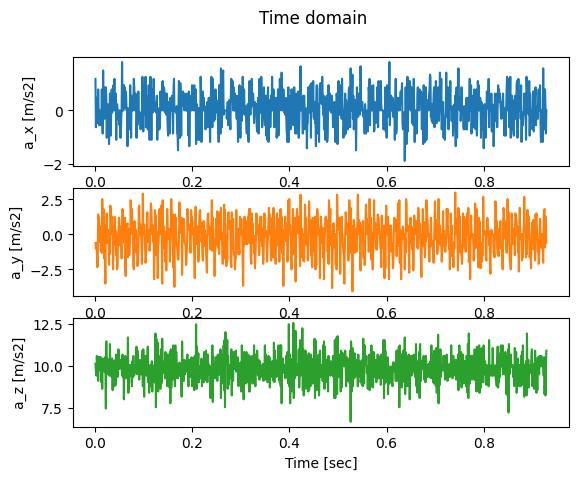

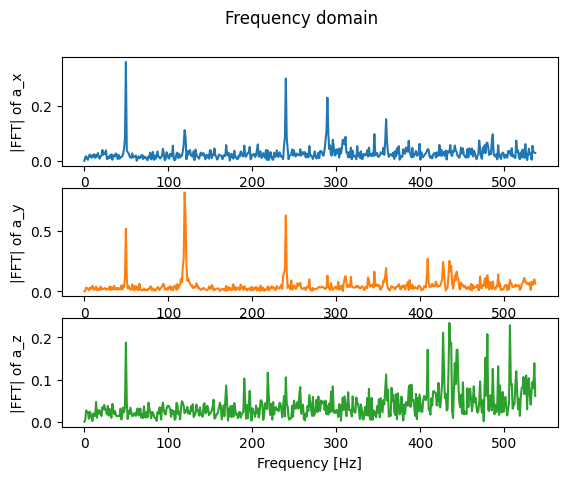

In [16]:
#Insert the block of code for processing and plotting here:
#
fig1, ax1 = plt.subplots(3)
fig1.suptitle('Time domain')
ax1[0].plot(t_normal,a_x_normal,'tab:blue')
ax1[0].set_ylabel('a_x [m/s2]')
ax1[1].plot(t_normal,a_y_normal, 'tab:orange')
ax1[1].set_ylabel('a_y [m/s2]')
ax1[2].plot(t_normal,a_z_normal, 'tab:green')
ax1[2].set_ylabel('a_z [m/s2]')
ax1[2].set_xlabel('Time [sec]')

f_x_normal, y_x_normal = get_fft(a_x_normal, T_normal, N_normal)
f_y_normal, y_y_normal = get_fft(a_y_normal, T_normal, N_normal)
f_z_normal, y_z_normal = get_fft(a_z_normal, T_normal, N_normal)

fig2, ax2 = plt.subplots(3)
fig2.suptitle('Frequency domain')
ax2[0].plot(f_x_normal,y_x_normal,'tab:blue')
ax2[0].set_ylabel('|FFT| of a_x')
ax2[1].plot(f_y_normal,y_y_normal,'tab:orange')
ax2[1].set_ylabel('|FFT| of a_y')
ax2[2].plot(f_z_normal,y_z_normal,'tab:green')
ax2[2].set_ylabel('|FFT| of a_z')
ax2[2].set_xlabel('Frequency [Hz]')

plt.show()

#

## 3.3 Signal Processing and plotting data from: Fan anomalous condition data

Reuse the code above to process the data and plot the signal for fan data in normal conditions.

HINT: Do not use the same variables names from code above. You will need all data information stored in different variables for Section 3.4

In [17]:
#Insert the block of code to upload the csv file here:
#

filename3 = './data/20260207_210936_lab2_abnormal.csv' #Insert the imported csv file name (copy the bolded text from the previous output) from the previous step inside the quotations
#Declaring arrays
dt_abnormal = [] # sampling period list, dt
t_abnormal = [] # time list, t
a_x_abnormal = [] # x-axis acceleration list, a_x
a_y_abnormal = [] # y-axis acceleration list, a_y
a_z_abnormal = [] # z-axis acceleration list, a_z

# Reading a CSV file and convert rows as data

with open(filename3, 'r') as f:
    rows = csv.reader(f, delimiter = ',')
    header = next(rows)
    for row in rows:
        dt_abnormal.append(float(row[0]))
        t_abnormal.append(float(row[1]))
        a_x_abnormal.append(float(row[2]))
        a_y_abnormal.append(float(row[3]))
        a_z_abnormal.append(float(row[4]))

#

In [18]:
#Insert the block of code for calculating time-domain features:
#Print out all time domain features in this block
#

N_abnormal = int(len(dt_abnormal)) # Number of sample = 1000
T_abnormal = t_abnormal[-1]/N_abnormal # sampling period, assumed equally distributed

n_abnormal = np.array(range(len(dt_abnormal))) + 1 # measured sequence
dt_abnormal = np.array(dt_abnormal) # convert dt list to dt 1D array
t_abnormal = np.array(t_abnormal) # convert t list to t 1D array
a_x_abnormal = np.array(a_x_abnormal) # convert a_x list to a_x 1D array
a_y_abnormal = np.array(a_y_abnormal) # convert a_y list to a_y 1D array
a_z_abnormal = np.array(a_z_abnormal) # convert a_z list to a_z 1D array

print(n_abnormal)
print(dt_abnormal)
print(t_abnormal)
print(a_x_abnormal)
print(a_y_abnormal)
print(a_z_abnormal)

#

[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  191  192  193  194  195  196
  197 

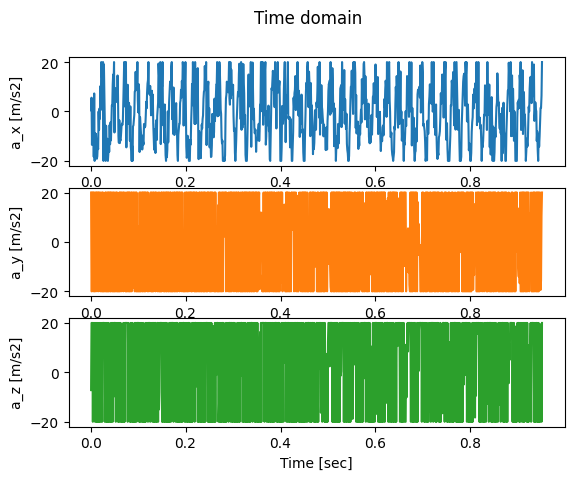

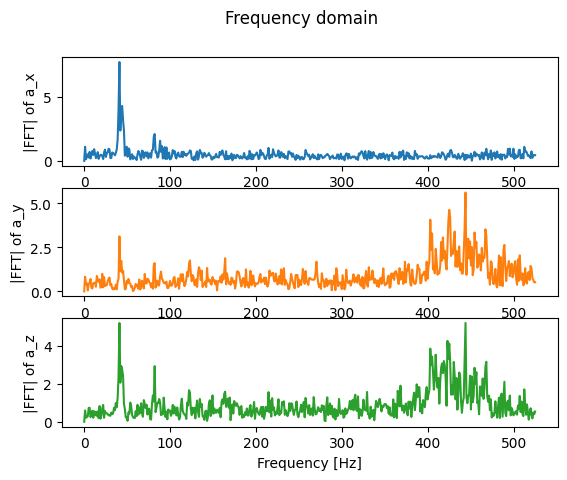

In [19]:
#Insert the block of code for processing and plotting here:
#
fig1, ax1 = plt.subplots(3)
fig1.suptitle('Time domain')
ax1[0].plot(t_abnormal,a_x_abnormal,'tab:blue')
ax1[0].set_ylabel('a_x [m/s2]')
ax1[1].plot(t_abnormal,a_y_abnormal, 'tab:orange')
ax1[1].set_ylabel('a_y [m/s2]')
ax1[2].plot(t_abnormal,a_z_abnormal, 'tab:green')
ax1[2].set_ylabel('a_z [m/s2]')
ax1[2].set_xlabel('Time [sec]')

f_x_abnormal, y_x_abnormal = get_fft(a_x_abnormal, T_abnormal, N_abnormal)
f_y_abnormal, y_y_abnormal = get_fft(a_y_abnormal, T_abnormal, N_abnormal)
f_z_abnormal, y_z_abnormal = get_fft(a_z_abnormal, T_abnormal, N_abnormal)

fig2, ax2 = plt.subplots(3)
fig2.suptitle('Frequency domain')
ax2[0].plot(f_x_abnormal,y_x_abnormal,'tab:blue')
ax2[0].set_ylabel('|FFT| of a_x')
ax2[1].plot(f_y_abnormal,y_y_abnormal,'tab:orange')
ax2[1].set_ylabel('|FFT| of a_y')
ax2[2].plot(f_z_abnormal,y_z_abnormal,'tab:green')
ax2[2].set_ylabel('|FFT| of a_z')
ax2[2].set_xlabel('Frequency [Hz]')

plt.show()

#

## 3.4 Contrasting time and frequency domain plots between datasets: Normal vs Anomalous

#### TASK 3.4

You will use the data you have worked through this Colab notebook. No need to re-run all codes.
1.	Make a comparative figure between the time-domain graphs on normal and anomalous data.

       * Column 1: Normal data, Column 2: Anomalous data

       * Row 1: a_x, Row 2: a_y, Row 3: a_z

2. Repeat 1. Make a comparative figure between the frequency-domain graphs on normal and anomalous data.
2.	Add your name at the end of the tile of each plot (e.g., ‘Time domain, John Doe’)


Text(0.5, 0, 'Frequency [Hz]')

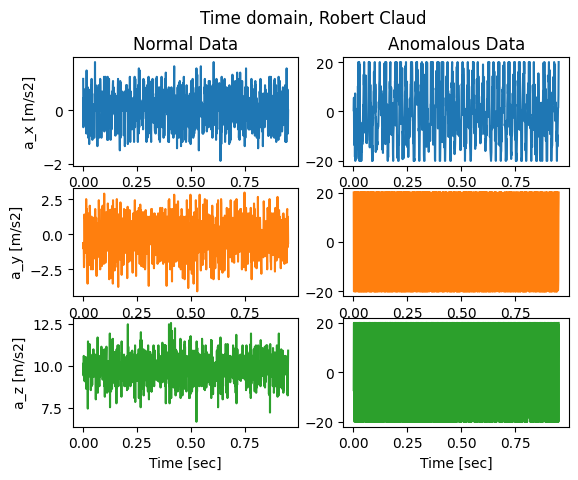

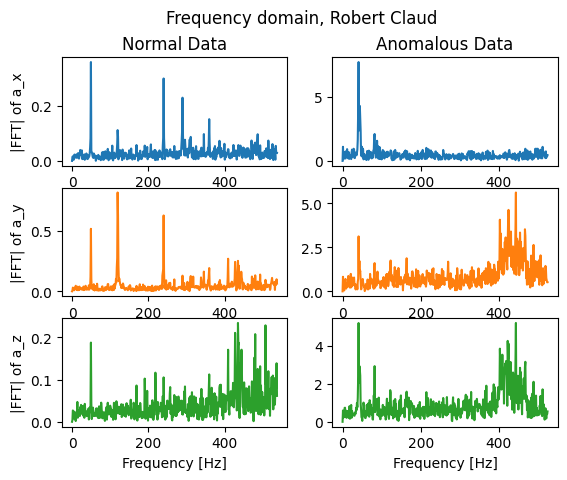

: 

In [ ]:
#Insert your code here:
#Provide comments to describe your code
#

# Time domain
fig1, ax1 = plt.subplots(3, 2) # create a 3x2 grid of subplots
fig1.suptitle('Time domain, Robert Claud') # set the overall title for the figure
ax1[0, 0].set_title('Normal Data') # set the title for the normal data
ax1[0, 1].set_title('Anomalous Data') # set the title for the anamalous data
ax1[0, 0].plot(t_abnormal,a_x_normal,'tab:blue') # plot the data for a_x under normal conditions
ax1[0, 1].plot(t_abnormal,a_x_abnormal,'tab:blue') # plot the data for a_x under abnormal conditions
ax1[0, 0].set_ylabel('a_x [m/s2]') # set the label for a_x
ax1[1, 0].plot(t_abnormal,a_y_normal, 'tab:orange') # plot the data for a_y under normal conditions
ax1[1, 1].plot(t_abnormal,a_y_abnormal, 'tab:orange') # plot the data for a_y under abnormal conditions
ax1[1, 0].set_ylabel('a_y [m/s2]') # set the label for a_y
ax1[2, 0].plot(t_abnormal,a_z_normal, 'tab:green') # plot the data for a_z under normal conditions
ax1[2, 1].plot(t_abnormal,a_z_abnormal, 'tab:green') # plot the data for a_z under abnormal conditions
ax1[2, 0].set_ylabel('a_z [m/s2]') # set the label for a_z
ax1[2, 0].set_xlabel('Time [sec]') # set the x-axis label for time for normal conditions
ax1[2, 1].set_xlabel('Time [sec]') # set the x-axis label for time for anomalous conditions

# Frequency domain
fig2, ax2 = plt.subplots(3, 2) # create a 3x2 grid of subplots
fig2.suptitle('Frequency domain, Robert Claud') # set the overall title for the figure
ax2[0, 0].set_title('Normal Data') # set the title for the normal data
ax2[0, 1].set_title('Anomalous Data') # set the title for the anomalous data
ax2[0, 0].plot(f_x_normal,y_x_normal,'tab:blue') # plot the data for a_x under normal conditions
ax2[0, 1].plot(f_x_abnormal,y_x_abnormal,'tab:blue') # plot the data for a_x under abnormal conditions
ax2[0, 0].set_ylabel('|FFT| of a_x') # set the label for a_x in the frequency domain
ax2[1, 0].plot(f_y_normal,y_y_normal,'tab:orange') # plot the data for a_y under normal conditions
ax2[1, 1].plot(f_y_abnormal,y_y_abnormal,'tab:orange') # plot the data for a_y under abnormal conditions
ax2[1, 0].set_ylabel('|FFT| of a_y') # set the label for a_y in the frequency domain
ax2[2, 0].plot(f_z_normal,y_z_normal,'tab:green') # plot the data for a_z under normal conditions
ax2[2, 1].plot(f_z_abnormal,y_z_abnormal,'tab:green') # plot the data for a_z under abnormal conditions
ax2[2, 0].set_ylabel('|FFT| of a_z') # set the label for a_z in the frequency domain
ax2[2, 0].set_xlabel('Frequency [Hz]') # set the x-axis label for frequency for the normal conditions
ax2[2, 1].set_xlabel('Frequency [Hz]') # set the x-axis label for frequency for the anomalous conditions

#


### Compare data of two conditions (normal vs. anomalous) of the axial flow fan.
  



#### 1) What contrast could be made between comparing time-domain characteristics of normal vs anomalous condition data?
---

In the time domain, the amplitude of the data is far higher for the anamolous condition data when compared to the time domain data. This is expected due to the increased vibration from adding a mass to the blade.

---

#### 2) What are the main frequencies and FFT magnitudes of each measurement?
---

<table>
  <tr>
    <th></th>
    <th colspan="2">Normal Conditions</th>
    <th colspan="2">Anamolous Conditions</th>
  </tr>
  <tr>
    <th></th>
    <th>Main Frequencies [Hz]</th>
    <th>FFT Magnitudes</th>
    <th>Main Frequencies [Hz]</th>
    <th>FFT Magnitudes [Hz]</th>
  </tr>
  <tr>
    <th>a_x</th>
    <th>50, 250, 300, 350</th>
    <th>0.4, 0.3, 0.2, 0.18</th>
    <th>50</th>
    <th>8</th>
  </tr>
  <tr>
    <th>a_y</th>
    <th>50, 100, 250</th>
    <th>0.5, 0.9, 0.7</th>
    <th>50</th>
    <th>3</th>
  </tr>
  <tr>
    <th>a_z</th>
    <th>50</th>
    <th>0.2</th>
    <th>50</th>
    <th>5</th>
  </tr>
</table>


---

#### 3) Which domain features are better to detect the abnormal condition of the fan? Explain why.
---

The frequency domain features are better to detect the abnormal condition of the fan because using the frequency domain allows specific peaks to be identified. In contrast, when using the time domain the abnormal data is too noisy to make out any useful information.

---

#### 4) From the three measured dimensions, Which dimension shows the best salient feature in order to detect vibration? Explain why.
---

The y-direction shows the best salient feature in order to detect vibration. This is because when the graphs between normal and anomalous conditions are compared, the normal conditions show three distinct peaks at relatively lower frequencies. However, under the anomalous conditions with more vibration, only the largest of these peaks can be seen and the rest is drowned out by high frequency noise. The z-axis also shows this noise at higher frequencies and all three graphs have large changes in magnitude, but the change is the greatest when comparing the y-axis.

---

## Lab2 Summary and Deliverables

Answer the following questions for your achievements




### Q1. Please summarize Lab2.

---

In lab 2, we learned how to connect to the ADXL345 accelerometer and take measurements from it. We were then able to save this data to a .csv file and perform time and frequency domain analysis on it using the fast fourier transform. To obtain different sets of data, we measured the vibration of a fan by placing the accelerometer on top of it and subjecting the fan to three different conditions:
1. The fan was turned off
2. The fan was run under normal conditions
3. A mass was attached to a fan blade and then the fan was run.

After data was obtained, the time and frequency domain charts were plotted and compared to one another.

---


### Q2. What skills did you have to develop to accomplish this project?

---

For this lab, I developed more skills with using the raspberry pi to connect to I2C sensors. I also developed better plotting skills using the matplotlib library. Finally, I developed problem solving skills since I had to make do with alternate materials from those listed in lab.

---

### Q3. What aspects of this project were the most beneficial for your learning?

---

Learning how to use the fast fourier transform and analyze the frequency domain was the most beneficial for my learning. I also appreciated taking real world data that I had collected and analyzing it myself.

---

### Q4. What challenges did you encounter in completing the project?

---

I encountered two main challenges in completing this project. The first was that I assumed that for this course I would be able to re-use the breadboard from ECE 201 instead of purchasing a smaller one, so I needed to make to with a significantly larger and heavier breadboard. The other challenge was that I did not have putty available at my house so I needed to find an alternative mass to use.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

To overcome these challenges, I dissassembled a portion of my breadboard to make it smaller and more manageable. I also used tape instead of an adhesive strip to secure the breadboard and sensor to the top of the fan. I also found a dime and taped this to one of the fan blades to act as a extra mass in place of putty.

---

<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)